# **Large-scale structure final notebook**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from config.settings import DATA_DIR, FIG_DIR

from config.plotting import Tab10, Tab20

## Load and prepare data

In [2]:
# bins = [[0.01, 0.04], [0.04, 0.08], [0.08, 0.12], [0.12, 0.16], [0.16, 0.20], [0.20, 0.40]]
# bin_names = ["001-004", "004-008", "008-012", "012-016", "016-020", "020-040"]

bins = [[0.01, 0.04], [0.04, 0.07], [0.07, 0.10], [0.10, 0.14], [0.14, 0.18], [0.18, 0.40]]
bin_names = ["001-004", "004-007", "007-010", "010-014", "014-018", "018-040"]

surveys = ["2mass", "6df", "sdss"]

### 1.1. Load data maps and random maps

In [3]:
data = []
rand = []

for i in range(len(surveys)):
    data_s = []
    rand_s = []
    for j in range(len(bin_names)):
        name_ij = f"{DATA_DIR/surveys[i]}/{surveys[i]}_{bin_names[j]}"
        data_s.append(np.load(f"{name_ij}_data.npy"))
        rand_s.append(np.load(f"{name_ij}_rand.npy"))
    data.append(data_s)
    rand.append(rand_s)

### 1.2. Normalize the random maps

In [4]:
for i in range(len(surveys)):
    for j in range(len(bin_names)):
        data_ij_size = np.sum(data[i][j])
        random_ij_size = np.sum(rand[i][j])
        alpha_ij = data_ij_size / random_ij_size
        rand[i][j] = np.float64(rand[i][j]) * alpha_ij
        new_alpha = data_ij_size / np.sum(rand[i][j])
        print(f"{surveys[i]}, {bin_names[j]}, DATA: {data_ij_size}, RANDOM: {random_ij_size:.0f}, 1/ratio = {1/alpha_ij:.2f}, after: {new_alpha:.2f}")

2mass, 001-004, DATA: 4616, RANDOM: 260272, 1/ratio = 56.38, after: 1.00
2mass, 004-007, DATA: 11378, RANDOM: 597749, 1/ratio = 52.54, after: 1.00
2mass, 007-010, DATA: 11423, RANDOM: 573643, 1/ratio = 50.22, after: 1.00
2mass, 010-014, DATA: 9365, RANDOM: 445111, 1/ratio = 47.53, after: 1.00
2mass, 014-018, DATA: 4237, RANDOM: 189000, 1/ratio = 44.61, after: 1.00
2mass, 018-040, DATA: 2083, RANDOM: 89255, 1/ratio = 42.85, after: 1.00
6df, 001-004, DATA: 34111, RANDOM: 1904523, 1/ratio = 55.83, after: 1.00
6df, 004-007, DATA: 45781, RANDOM: 2281222, 1/ratio = 49.83, after: 1.00
6df, 007-010, DATA: 21518, RANDOM: 955854, 1/ratio = 44.42, after: 1.00
6df, 010-014, DATA: 8265, RANDOM: 360992, 1/ratio = 43.68, after: 1.00
6df, 014-018, DATA: 2144, RANDOM: 94955, 1/ratio = 44.29, after: 1.00
6df, 018-040, DATA: 1545, RANDOM: 72364, 1/ratio = 46.84, after: 1.00
sdss, 001-004, DATA: 638, RANDOM: 30900, 1/ratio = 48.43, after: 1.00
sdss, 004-007, DATA: 7714, RANDOM: 373203, 1/ratio = 48.38, af

### 1.3. Masks

In [5]:
masks = []

for i in range(len(surveys)):
    masks.append(np.load(f"{DATA_DIR/surveys[i]}/{surveys[i]}_mask.npy"))

In [6]:
from astropy.coordinates import SkyCoord

MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg')
theta_MW, phi_MW = np.pi/2 - MW_plane.galactic.b.rad, MW_plane.galactic.l.rad

EQ_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg')
theta_EQ, phi_EQ = np.pi/2 - MW_plane.galactic.b.rad, MW_plane.galactic.l.rad

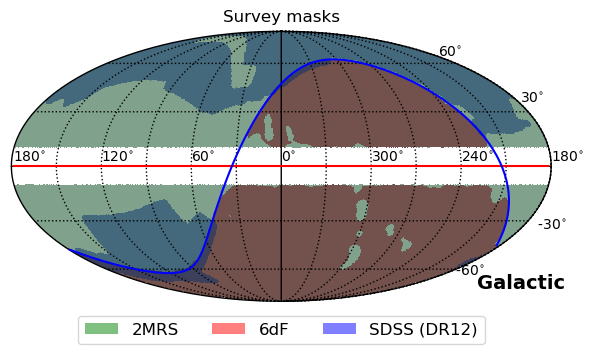

In [7]:
from matplotlib.patches import Patch

cmaps = ["Greens", "Reds", "Blues"]
colors = ["green", "red","blue"]
names = ["2MRS", "6dF", "SDSS (DR12)"]

plt.figure(figsize=(7, 4))
ax = plt.subplot(111)
plt.sca(ax)

legend_elements = []

for i in range(len(surveys)):
    legend_elements.append(Patch(facecolor=colors[i], alpha=0.5, label=names[i]))
    if i == 0:
        hp.mollview(masks[i],alpha=0.5*masks[i], cmap=cmaps[i], cbar=False, coord=['C', 'G'], xsize=900, hold=True,
                    title="Survey masks")
    else:
        hp.mollview(masks[i], reuse_axes=True, alpha=0.5 * masks[i], cmap=cmaps[i], cbar=False, xsize=900, title="Survey masks",
                    coord='C', notext=True)
        
hp.graticule()

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='C')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

plt.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.1), ncol=3, loc='center', fontsize=12)
plt.savefig(f"{FIG_DIR}/lss-masks.png", bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

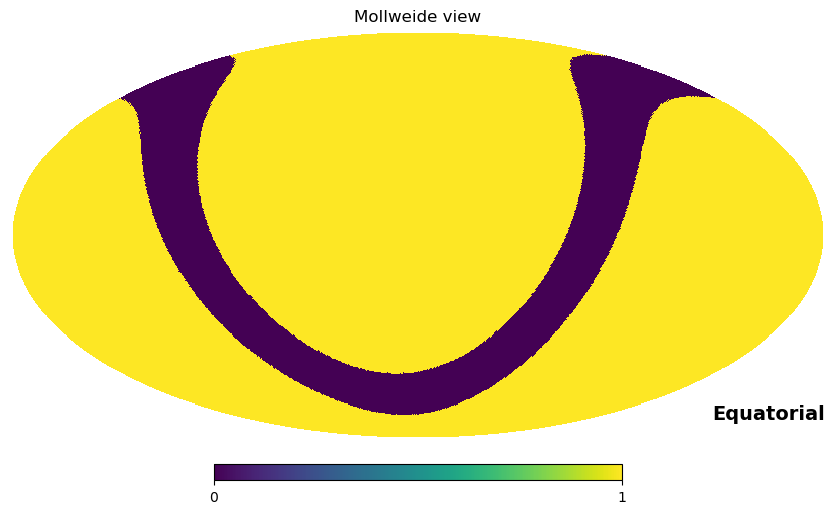

In [8]:
mask_total = (np.sum(masks, axis=0) > 0)
hp.mollview(mask_total, coord='C', rot=(180, 0, 0))

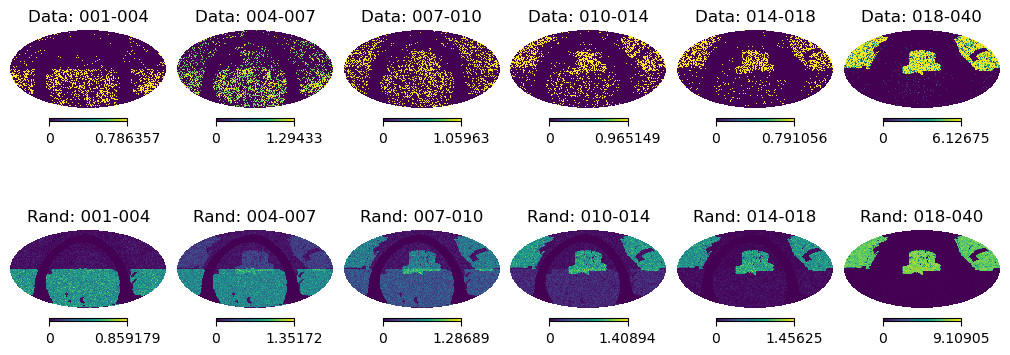

In [9]:
# Define the grid dimensions
n_bins = len(bin_names)
nrows = 2
ncols = n_bins # One for data, one for rand

# Create one large figure to hold everything
fig = plt.figure(figsize=(10, 2 * nrows))

new_data = []
new_rand = []

for j in range(n_bins):
    # ... your data processing logic ...
    new_data_j = np.sum([data[i][j] * masks[i] for i in range(len(surveys))], axis=0)
    new_rand_j = np.sum([rand[i][j] * masks[i] for i in range(len(surveys))], axis=0)

    # Plot Data in the left column (odd indices: 1, 3, 5...)
    hp.mollview(
        new_data_j, min=0, max=4 * np.mean(new_data_j),
        sub=(nrows, ncols, 1 + j), 
        title=f"Data: {bin_names[j]}",
        hold=False
    )
    
    # Plot Rand in the right column (even indices: 2, 4, 6...)
    hp.mollview(
        new_rand_j, 
        sub=(nrows, ncols, 1 + j + ncols), 
        title=f"Rand: {bin_names[j]}",
        hold=False
    )
    
    new_data.append(new_data_j)
    new_rand.append(new_rand_j)

plt.show()

In [10]:
from astropy.cosmology import LambdaCDM
import astropy.units as u

In [11]:
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
bins_d = cosmo.comoving_distance(np.array(bins))

In [12]:
# CLUSTERS
import pandas as pd
from astropy.coordinates import SkyCoord
clusters = pd.read_csv("./galcats/clusters.csv")
clusters

clusters_coords = SkyCoord(clusters["RA"], clusters["Dec"], frame='icrs').galactic

5.381739590286252
2.4632350684414246
1.60512097267173
1.1465030439567354
1.0
1.0


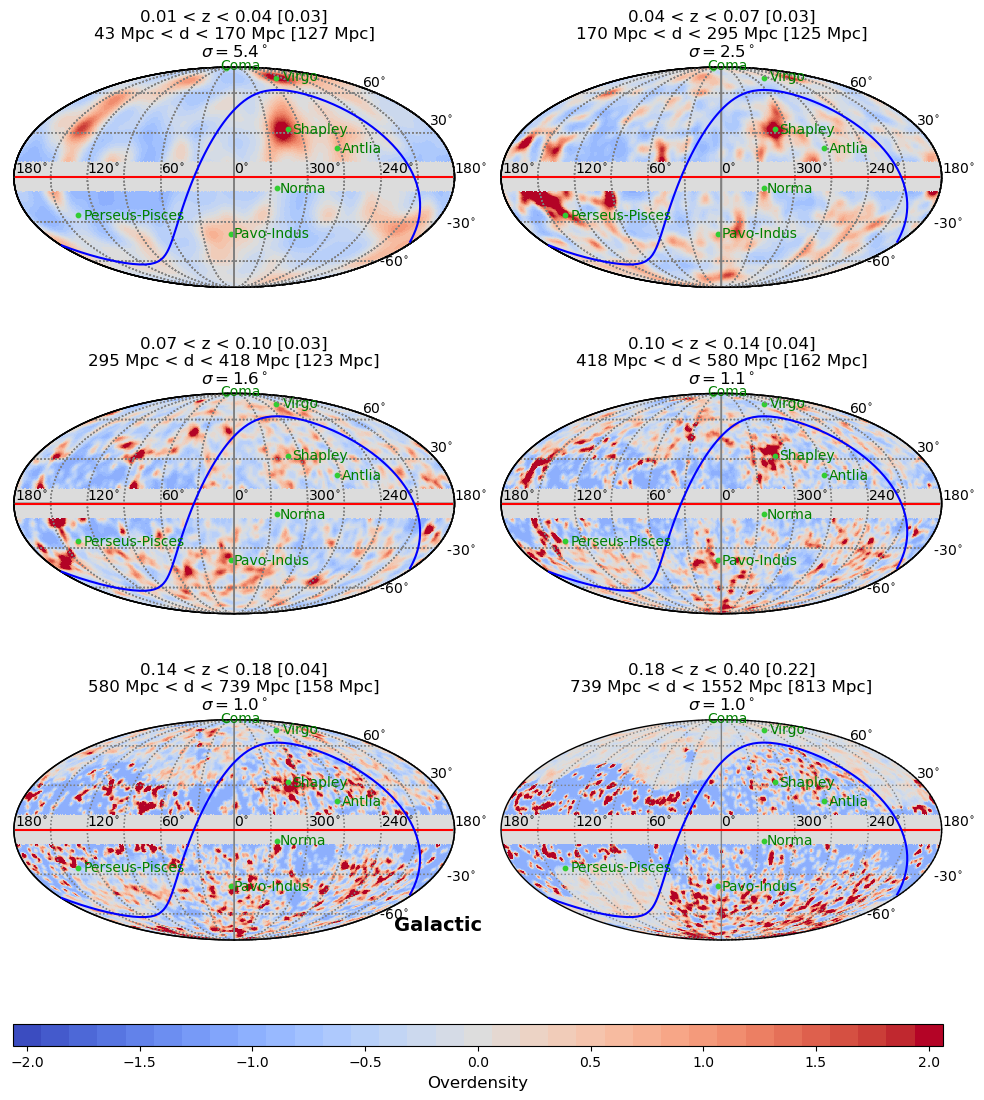

In [13]:
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from scipy.stats import norm

# 1. Create a figure and define a grid
fig = plt.figure(figsize=(12, 13))

# GridSpec: n_bins rows, 6 columns 
# (4 columns for maps, 1 for histograms, 1 for a bit of padding/colorbar space)
# Add one extra row for the colorbar
gs = gridspec.GridSpec(4, 2, wspace=0.1, hspace=0.3, height_ratios=[12, 12, 12, 1])

cmap_norm = plt.Normalize(vmin=-2.0625, vmax=2.0625)
cmap = plt.get_cmap('coolwarm', lut=33)

maps_final = []

for j in range(len(bin_names)):
    # Old procedure: ratio -> smooth
    # delta_j = np.zeros_like(data[0][0], dtype=np.float64) 
    # mask_total_j = mask_total * (new_rand[j] > 0)
    # delta_j[mask_total_j] = new_data[j][mask_total_j] / new_rand[j][mask_total_j] - 1
    # delta_j_s = hp.smoothing(delta_j, sigma=np.deg2rad(2.0))
    
    # New procedure: smooth -> ratio
    z_avg = (bins[j][0] + bins[j][1])/2
    d_avg = (bins_d[j][0] + bins_d[j][1]).to_value(u.Mpc)/2
    sm_deg = np.max(((10 * u.Mpc / cosmo.kpc_comoving_per_arcmin(z_avg)).to_value(u.deg), 1.0))
    print(sm_deg)
    new_data_smooth = hp.smoothing(new_data[j], sigma=np.deg2rad(sm_deg))
    new_rand_smooth = hp.smoothing(new_rand[j], sigma=np.deg2rad(sm_deg))
    delta_j_s = np.zeros_like(new_data[j], dtype=np.float64) 
    delta_j_s[mask_total] = new_data_smooth[mask_total] / new_rand_smooth[mask_total] - 1
        
    # 2. Plot the Map (occupies columns 0 to 3)
    # The 'sub' parameter takes (nrows, ncols, plot_number)
    ax = fig.add_subplot(gs[j//2, j%2]) # Create the axis where you want it
    plt.sca(ax)                     # Set Current Axis to the one we just made
    hp.mollview(
        delta_j_s * mask_total, 
        min=-2.0625, max=2.0625, 
        coord=['C', 'G'],
        cmap=cmap,
        cbar=False,
        title=f"{bins[j][0]:.2f} < z < {bins[j][1]:.2f} [{bins[j][1] - bins[j][0]:.2f}]\n"
              f"{bins_d[j][0]:.0f} < d < {bins_d[j][1]:.0f} [{bins_d[j][1] - bins_d[j][0]:.0f}]\n"
              r"$\sigma = $"f"{sm_deg:.1f}"r"${}^\circ$",
        sub=None,
        notext=(j != 4),
        hold=True
    )
    hp.graticule(color='gray')
    maps_final.append(delta_j_s * mask_total)
    
    # # 3. Plot the Distribution (occupies column 4)
    # ax_hist = fig.add_subplot(gs[j, 1])
    
    # # Flatten and filter to only plot valid data within the mask
    # plot_vals = delta_j_s[mask_total]
    # x = np.linspace(-3, 11, 100)
    # pdf = norm.pdf(x, loc=np.mean(plot_vals), scale=np.std(plot_vals))
    
    # h_bins = np.arange(-2, 20.5, 0.1)
    # ax_hist.hist(plot_vals, bins=h_bins, color='gray', alpha=0.7, rasterized=True)
    # ax_hist.plot(x, pdf * np.sum(mask_total) * 0.1)
    # ax_hist.vlines([np.mean(plot_vals)], 1e0, 1e5, linestyle='dashed')
    
    # if j == 3:
    #     ax_hist.set_xlabel("Overdensity")
    # ax_hist.set_xlim(-1, 5)
    # ax_hist.set_xticks([-1, 0, 1, 2, 3, 4, 5])

    # ax_hist.set_ylim(1, 1e5)
    # ax_hist.set_yscale('log')

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='C')
hp.projscatter(np.pi/2 - clusters_coords.b.rad, clusters_coords.l.rad, marker='o', s=10, color='limegreen')
for k in range(clusters["Name"].size):
    hp.projtext(np.pi/2 - clusters_coords.b.rad[k] + 0.05, clusters_coords.l.rad[k] - 0.05,
                f"{clusters['Name'][k]}", color='green')
    
for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180), f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")
    
# 3. Add the Single Global Colorbar
# We'll place it to the right of all the plots
# Place colorbar in the last row, spanning the map columns (0 to 4)
cbar_ax = fig.add_subplot(gs[3, :])
cb = fig.colorbar(cm.ScalarMappable(norm=cmap_norm, cmap=cmap),
                  cax=cbar_ax, orientation='horizontal', aspect=40)
cb.set_label('Overdensity', fontsize=12)

# plt.savefig("lss-final.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

In [14]:
## save overdensity maps
for i in range(len(bins)):
    np.save(f"./overdensity/maps{bin_names[i]}", maps_final[i])